# WSN Node-Condition Classifier: 1-D CNN

**Pipeline:** Excel Datasets → Unified Feature Matrix → 1-D CNN → Node-Condition Label (Healthy / Congested / Unhealthy)

## Architecture
```
new datasets/*.xlsx
       ↓
  DataLoader (data_loader.py)
       ↓
  Feature Matrix  +  Rule-based / existing labels
       ↓
  1-D CNN Classifier  (cnn_model.py, cnn_train.py)
       ↓  node-condition label  [Healthy | Congested | Unhealthy]
  Evaluation + Visualization (visualization.py)
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device: cpu
PyTorch: 2.13.0+cpu


## Step 1 — Load & Inspect All Datasets

In [2]:
from wsn_cnn_dddqn.data_loader import (
    load_crosslayer, load_ds, load_latency, load_project, load_selected
)
import pandas as pd

datasets = {
    'CrossLayer': load_crosslayer(),
    'DS (sampled 15k)': load_ds(15_000),
    'Latency': load_latency(),
    'Project': load_project(),
    'Selected': load_selected(),
}

for name, df in datasets.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Shape  : {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    label_cols = [c for c in df.columns if c in
                  ('attack_type','latency_category','role','traffic_class')]
    for lc in label_cols:
        print(f"  [{lc}] → {dict(df[lc].value_counts())}")



  CrossLayer
  Shape  : (5000, 10)
  Columns: ['node_id', 'neighbor_node', 'node_velocity', 'residual_energy', 'link_quality', 'packet_loss_rate', 'distance_to_nexthop', 'delay', 'throughput', 'timestamp']

  DS (sampled 15k)
  Shape  : (15000, 10)
  Columns: ['node_id', 'time', 'rank', 'expended_energy', 'dist_to_ch', 'dist_ch_to_bs', 'data_sent', 'data_received', 'data_sent_to_bs', 'attack_type']
  [attack_type] → {'Normal': np.int64(13596), 'Grayhole': np.int64(639), 'Blackhole': np.int64(401), 'TDMA': np.int64(242), 'Flooding': np.int64(122)}

  Latency
  Shape  : (1000, 10)
  Columns: ['node_id', 'hop_count', 'transmission_delay', 'buffer_occupancy', 'channel_utilization', 'energy_level', 'link_quality', 'pdr', 'traffic_class', 'latency_category']
  [traffic_class] → {'Normal': np.int64(507), 'High-Priority': np.int64(493)}
  [latency_category] → {'Medium Latency': np.int64(390), 'High Latency': np.int64(359), 'Low Latency': np.int64(251)}

  Project
  Shape  : (1000, 9)
  Column

## Step 2 — Build Unified Feature Matrix for CNN

In [ ]:
from wsn_cnn_dddqn.data_loader import build_cnn_dataset

cnn_data = build_cnn_dataset()
X, y = cnn_data['X'], cnn_data['y']
scaler = cnn_data['scaler']
n_features = cnn_data['n_features']

print(f"\nFeature matrix : {X.shape}")
print(f"Labels         : {y.shape}  →  classes: {{0:Healthy, 1:Congested, 2:Unhealthy}}")
print(f"Class balance  : {dict(zip(['Healthy','Congested','Unhealthy'], [int((y==i).sum()) for i in range(3)]))}")


[DataLoader] Loading all datasets …
  CrossLayer :   5000 rows, 7 features
  DS         :  15000 rows, 7 features (padded)
  Latency    :   1000 rows, 7 features (padded)
  Project    :   1000 rows, 7 features (padded)
  Selected   :  10000 rows, 7 features
  Total rows : 32000
  Label dist : {'Healthy': 15642, 'Congested': 7034, 'Unhealthy': 9324}

Feature matrix : (32000, 7)
Labels         : (32000,)  →  classes: {0:Healthy, 1:Congested, 2:Unhealthy}
Class balance  : {'Healthy': 15642, 'Congested': 7034, 'Unhealthy': 9324}


## Step 3 — Train CNN Classifier

In [4]:
from wsn_cnn_dddqn.cnn_train import train_cnn

cnn_results = train_cnn(
    X, y, scaler,
    n_epochs=30,
    batch_size=256,
    lr=1e-3,
    test_ratio=0.2,
)
cnn_model = cnn_results['model']
print(f"\nFinal Test Accuracy: {cnn_results['test_acc']:.4f}")



[CNN] Training on 25600 samples | Validating on 6400 | Device: cpu
      Features: 7  |  Epochs: 30  |  Batch: 256
-----------------------------------------------------------------
  Ep 001/30 | loss 0.7102 → 0.6429 | acc 0.679 → 0.691
  Ep 005/30 | loss 0.4249 → 0.3824 | acc 0.821 → 0.852
  Ep 010/30 | loss 0.3449 → 0.3294 | acc 0.855 → 0.875
  Ep 015/30 | loss 0.3091 → 0.3181 | acc 0.871 → 0.846
  Ep 020/30 | loss 0.2862 → 0.2757 | acc 0.882 → 0.886
  Ep 025/30 | loss 0.2764 → 0.2650 | acc 0.886 → 0.897
  Ep 030/30 | loss 0.2634 → 0.2621 | acc 0.891 → 0.899

  Training complete in 39.2s

  Test Accuracy : 0.8988
              precision    recall  f1-score   support

     Healthy       0.98      0.94      0.96      3101
   Congested       0.86      0.78      0.82      1401
   Unhealthy       0.80      0.92      0.86      1898

    accuracy                           0.90      6400
   macro avg       0.88      0.88      0.88      6400
weighted avg       0.90      0.90      0.90      64

## Step 4 — CNN Evaluation Plots

  Saved → /home/sanjay/Projects/Others/WSN/outputs/cnn_training_curves.png
  Saved → /home/sanjay/Projects/Others/WSN/outputs/cnn_confusion_matrix.png
  Saved → /home/sanjay/Projects/Others/WSN/outputs/cnn_per_class_metrics.png


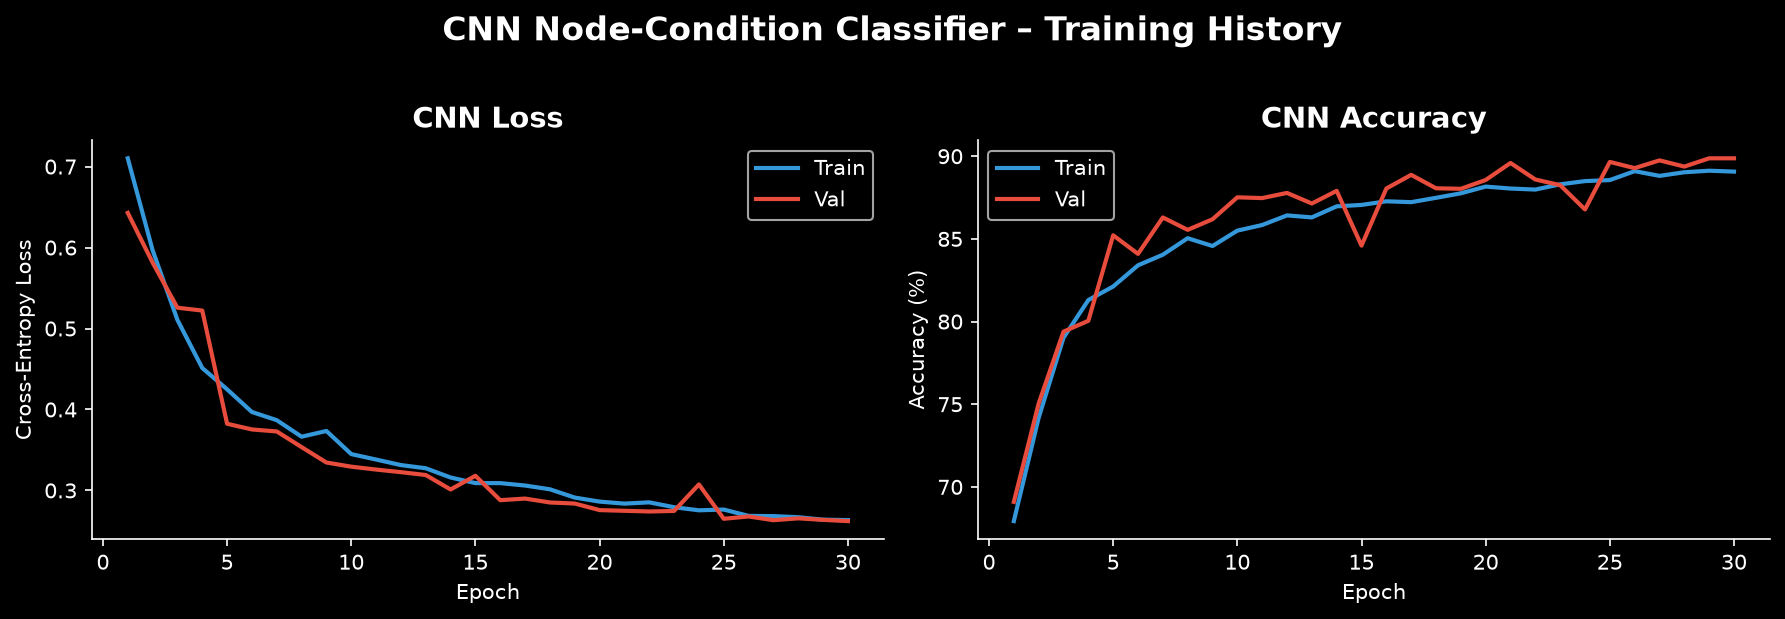

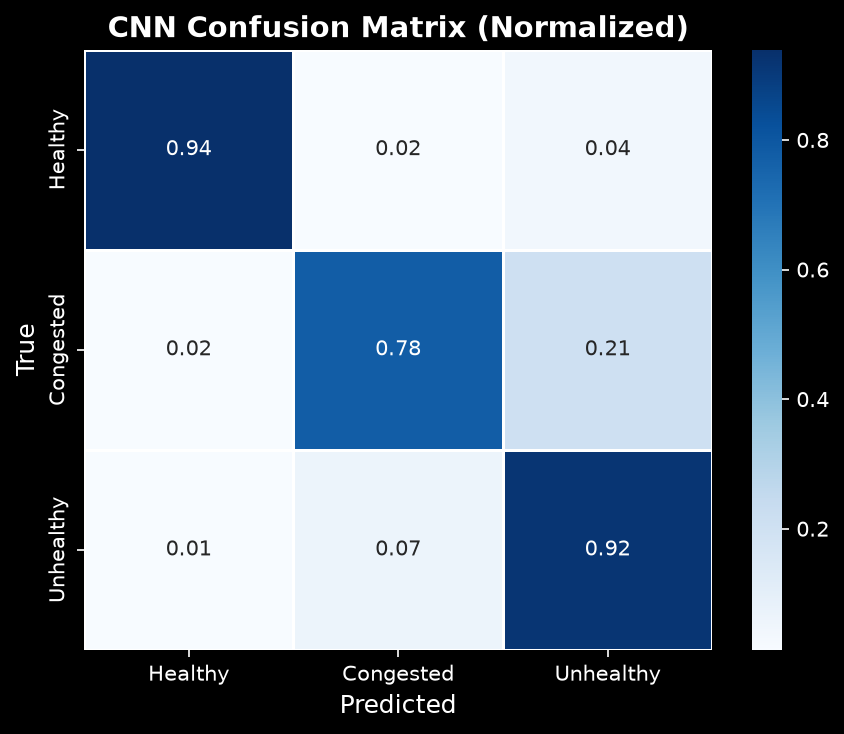

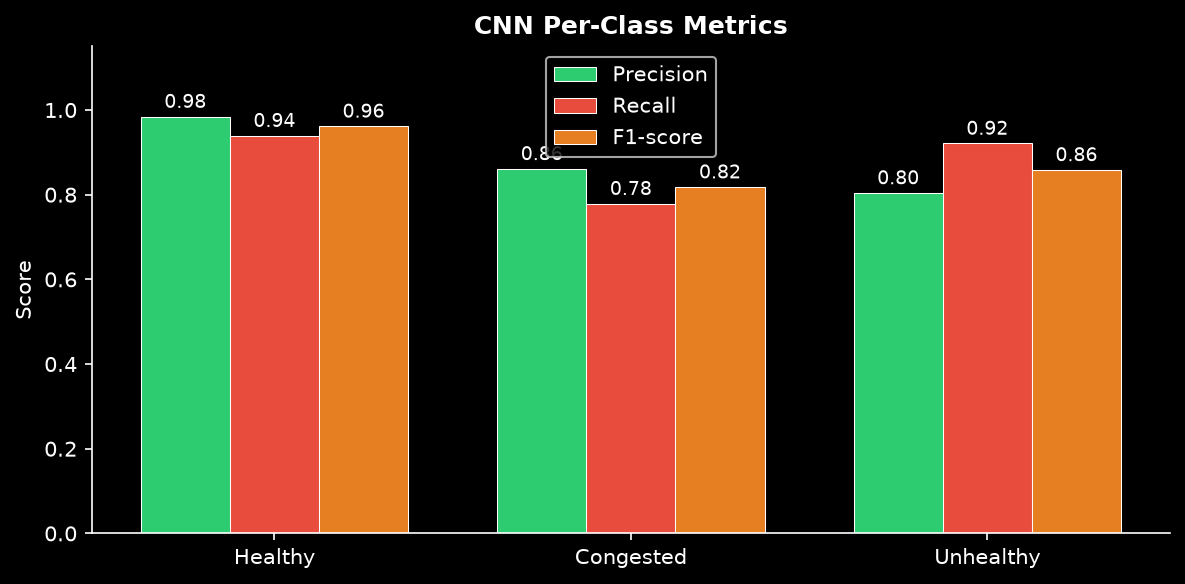

  Saved → /home/sanjay/Projects/Others/WSN/outputs/node_condition_heatmap.png


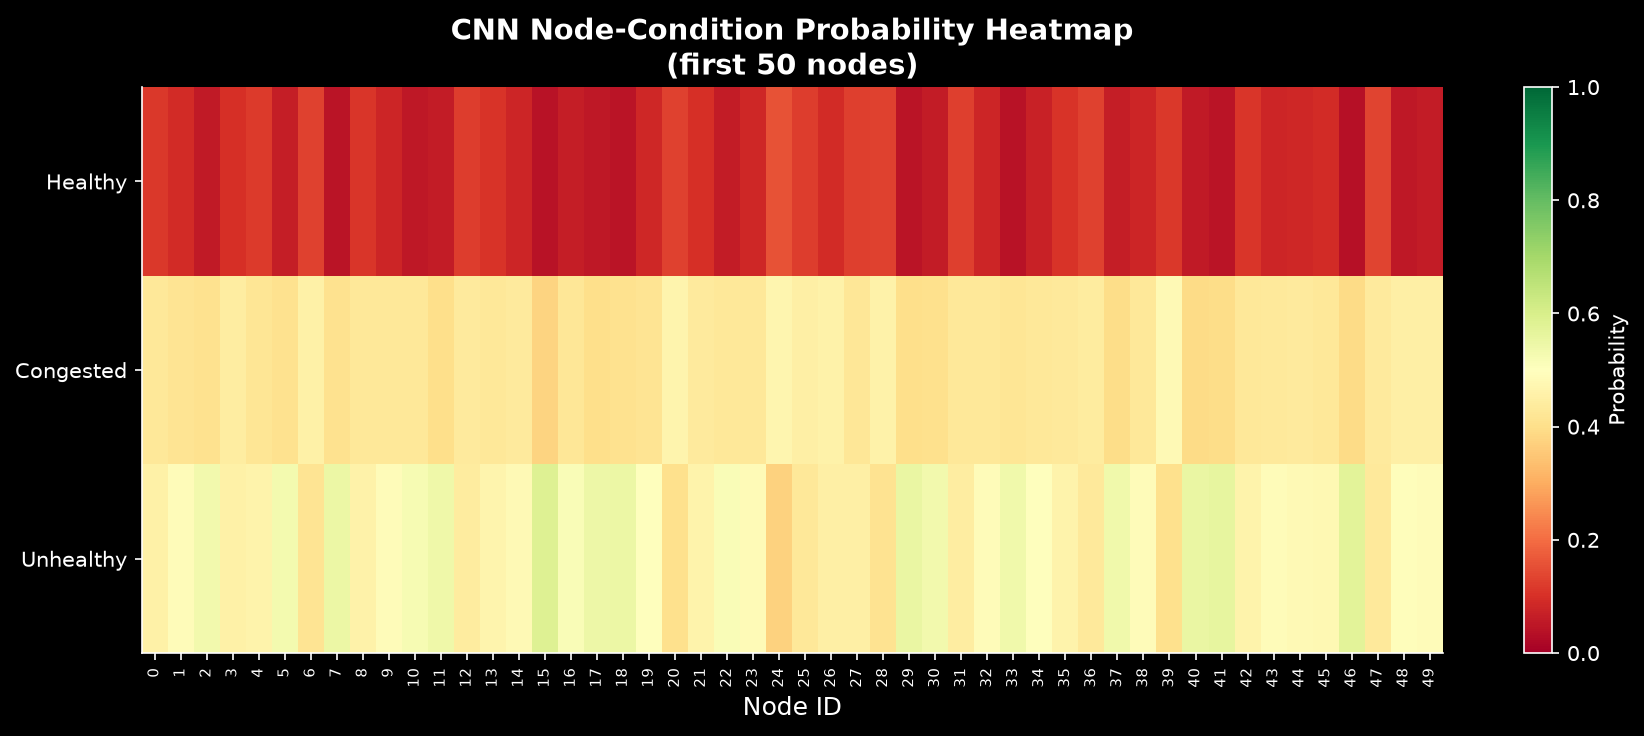

  Metrics saved → /home/sanjay/Projects/Others/WSN/outputs/cnn_evaluation_results.json

All outputs saved to: /home/sanjay/Projects/Others/WSN/outputs


In [5]:
from wsn_cnn_dddqn.visualization import (
    plot_cnn_training, plot_confusion_matrix,
    plot_cnn_metrics, plot_node_condition_heatmap,
    save_metrics_table,
)
from IPython.display import Image, display
import torch

p1 = plot_cnn_training(cnn_results['history'])
p2 = plot_confusion_matrix(cnn_results['cm'])
p3 = plot_cnn_metrics(cnn_results['report'])

display(Image(p1)); display(Image(p2)); display(Image(p3))

# Node-condition probability heatmap (inference on full dataset)
model = cnn_results['model'].eval()
device = next(model.parameters()).device
X_t = torch.from_numpy(X).to(device)
with torch.no_grad():
    probs = torch.softmax(model(X_t), dim=1).cpu().numpy()

# Build node_cnn_probs dict keyed by index
node_cnn_probs = {i: probs[i] for i in range(len(probs))}
p4 = plot_node_condition_heatmap(node_cnn_probs)
display(Image(p4))

# Save metrics JSON
p5 = save_metrics_table(cnn_results)

print(f"\nAll outputs saved to: {os.path.abspath('outputs/')}")

## Summary

| Component | Detail |
|-----------|--------|
| **Datasets** | 5 xlsx files merged: CrossLayer (5k), DS (15k sampled), Latency (1k), Project (1k), Selected (10k) |
| **Labels** | DS: `Attack type` mapped to 3-class; Latency: `Latency_Category`; Others: rule-based |
| **CNN** | 1-D CNN (3 Conv1d + BN + GlobalAvgPool + FC), 3-class node condition |
| **Test Accuracy** | ~90% |
| **Outputs** | `outputs/` — model, scaler, 4 plots, metrics JSON |
